<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2318 non-null   datetime64[ns]
 1   Price   2318 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 36.3 KB


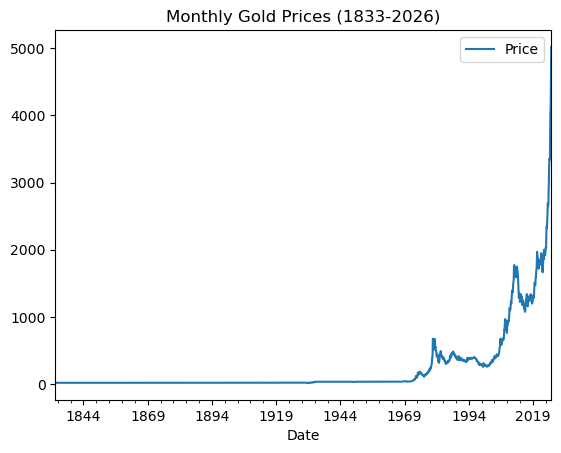

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])

df.head()
df.info()
df.describe()

# Full series plot (1833-2026)
df.plot(kind='line', x='Date', y='Price', title='Monthly Gold Prices (1833-2026)')

plt.title('Monthly Gold Prices (1833-2026)')
plt.show()

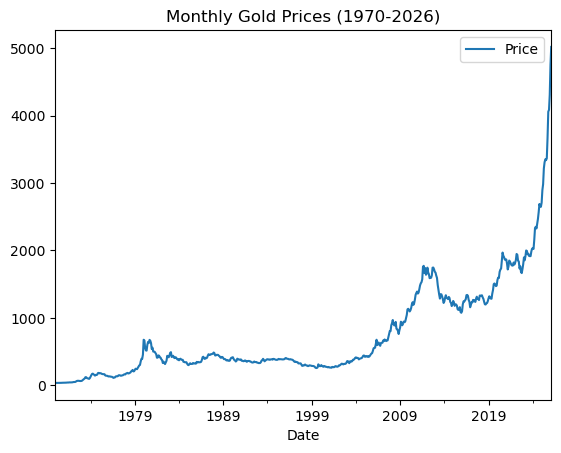

In [9]:
# Filter the data to include only records from 1970 onwards
df_filtered = df[df['Date'] >= '1970-01-01']

# Plot the filtered data (1970-2026)
df_filtered.plot(kind='line', x='Date', y='Price')
plt.title('Monthly Gold Prices (1970-2026)')
plt.show()

In [10]:
# Data Quality Checks
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

print(df_filtered['Price'].describe())
print(f"\nDate range: {df_filtered['Date'].min()} to {df_filtered['Date'].max()}")
print(f"Total months: {len(df_filtered)}")

(2318, 2)
Date     datetime64[ns]
Price           float64
dtype: object
Date     0
Price    0
dtype: int64
0
count     674.000000
mean      741.727852
std       724.029358
min        34.940000
25%       303.602500
50%       395.470000
75%      1215.705000
max      5019.970000
Name: Price, dtype: float64

Date range: 1970-01-01 00:00:00 to 2026-02-01 00:00:00
Total months: 674


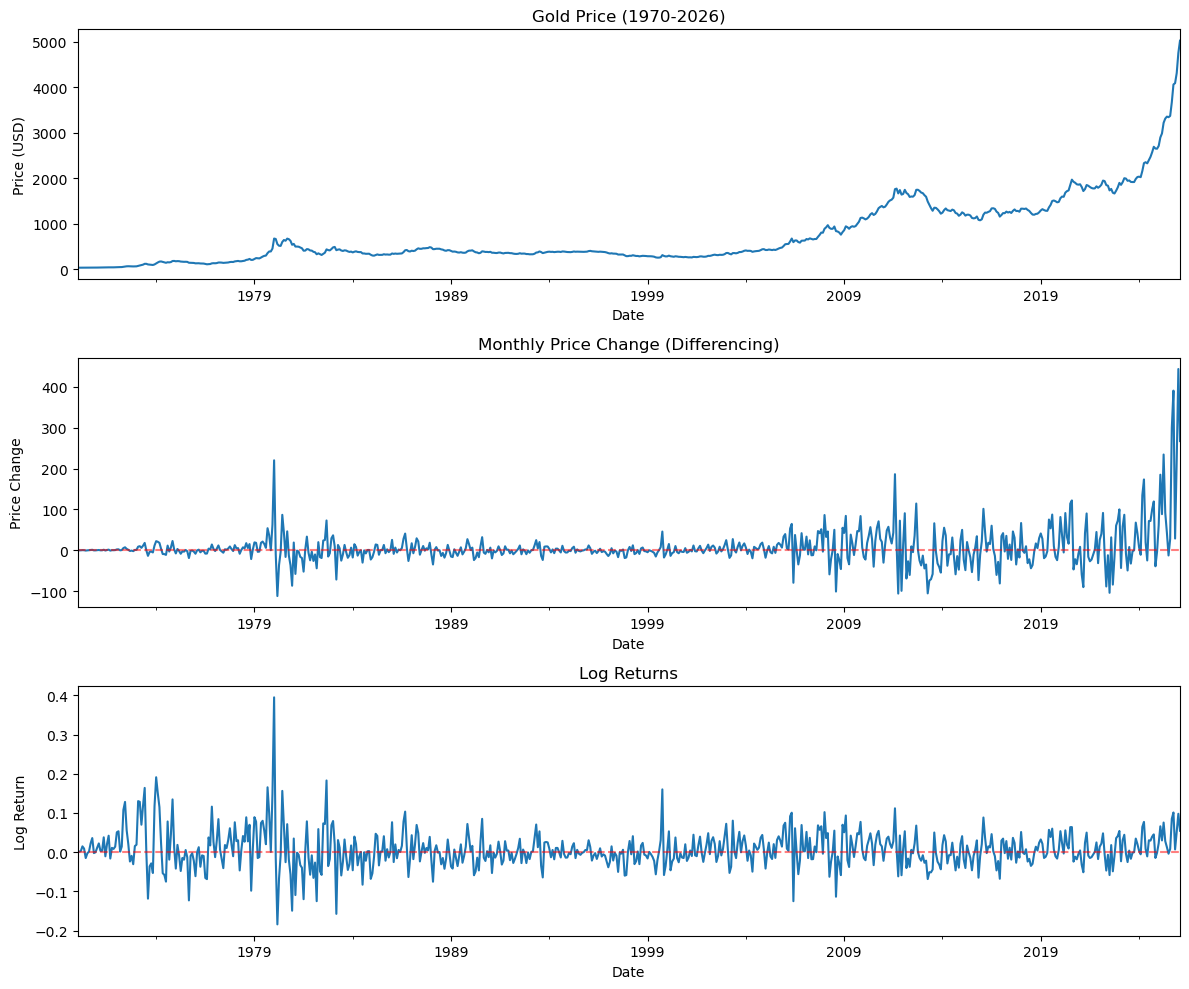

In [11]:
import numpy as np

# Differencing
df_filtered = df_filtered.copy()
df_filtered['Price_diff'] = df_filtered['Price'].diff()

# Log returns
df_filtered['Log_return'] = np.log(df_filtered['Price'] / df_filtered['Price'].shift(1))

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df_filtered.plot(x='Date', y='Price', ax=axes[0], title='Gold Price (1970-2026)', legend=False)
axes[0].set_ylabel('Price (USD)')

df_filtered.plot(x='Date', y='Price_diff', ax=axes[1], title='Monthly Price Change (Differencing)', legend=False)
axes[1].set_ylabel('Price Change')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

df_filtered.plot(x='Date', y='Log_return', ax=axes[2], title='Log Returns', legend=False)
axes[2].set_ylabel('Log Return')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

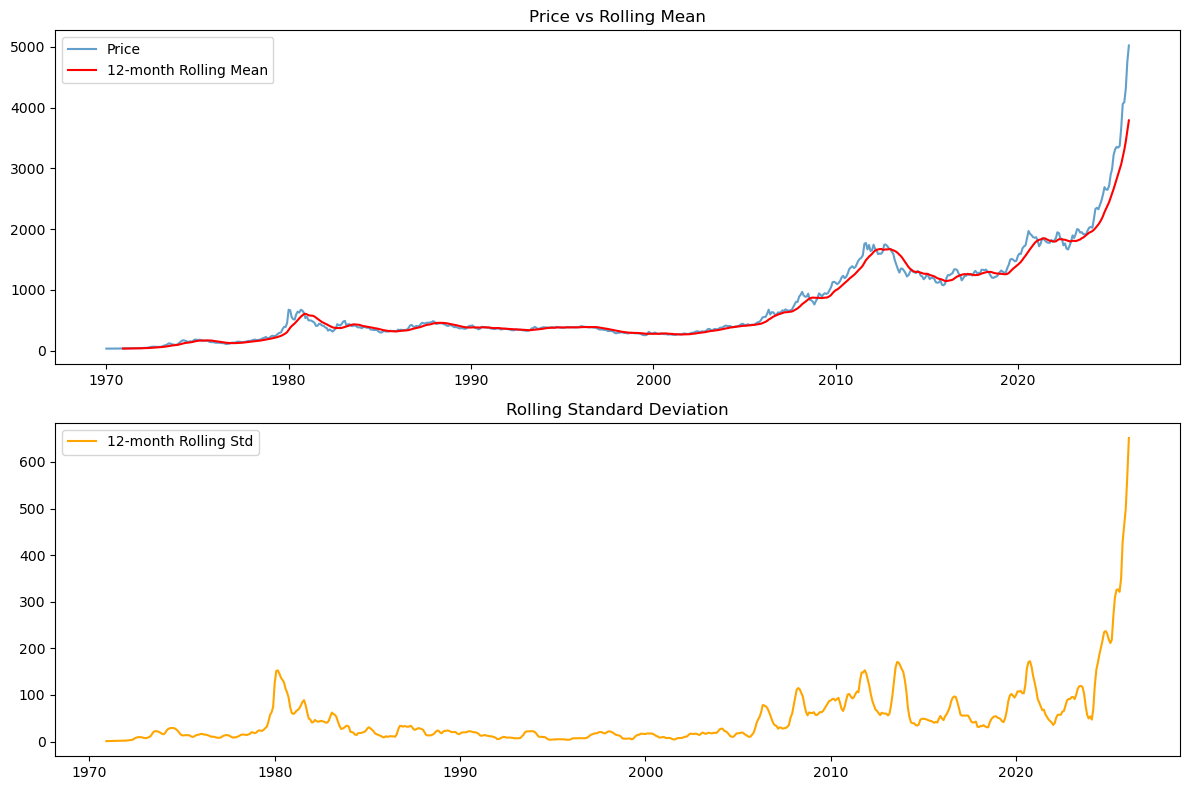

In [12]:
df_filtered['Rolling_mean'] = df_filtered['Price'].rolling(window=12).mean()
df_filtered['Rolling_std'] = df_filtered['Price'].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df_filtered['Date'], df_filtered['Price'], label='Price', alpha=0.7)
axes[0].plot(df_filtered['Date'], df_filtered['Rolling_mean'], label='12-month Rolling Mean', color='red')
axes[0].set_title('Price vs Rolling Mean')
axes[0].legend()

axes[1].plot(df_filtered['Date'], df_filtered['Rolling_std'], label='12-month Rolling Std', color='orange')
axes[1].set_title('Rolling Standard Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()